In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable
from res import *

combined_mask : has schema Schema({'lod_level': UInt8, 'lod_code': String, 'face': String, 'i': UInt32, 'j': UInt32, 'row_id': UInt32}) and       additional information Parquet SCAN [C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33-Database-Refinement-Improved\data_products\combined_mask.parquet]
PROJECT */6 COLUMNS
ESTIMATED ROWS: 100728072
combined_atlas : has schema Schema({'face': String, 'i': UInt32, 'j': UInt32, 'uint8_reflectance': UInt8, '32bit_reflectance': Float32, 'positions_x': Float32, 'positions_y': Float32, 'positions_z': Float32}) and       additional information Parquet SCAN [C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33-Database-Refinement-Improved\data_products\combined_atlas.parquet]
PROJECT */8 COLUMNS
ESTIMATED ROWS: 402653184
mask_atlas_combined : has schema Schema({'lod_level': UInt8, 'lod_code': String, 'face': String, 'i': UInt32, 'j': UInt32, 'row_id': UInt32, 'uint8_reflectance': UInt8, '32bit_reflectance': Float32, 'positions_x'

In [3]:
from quick_calculate import FittingFunction
from functools import partial

fit = FittingFunction(LAD_min = 2)

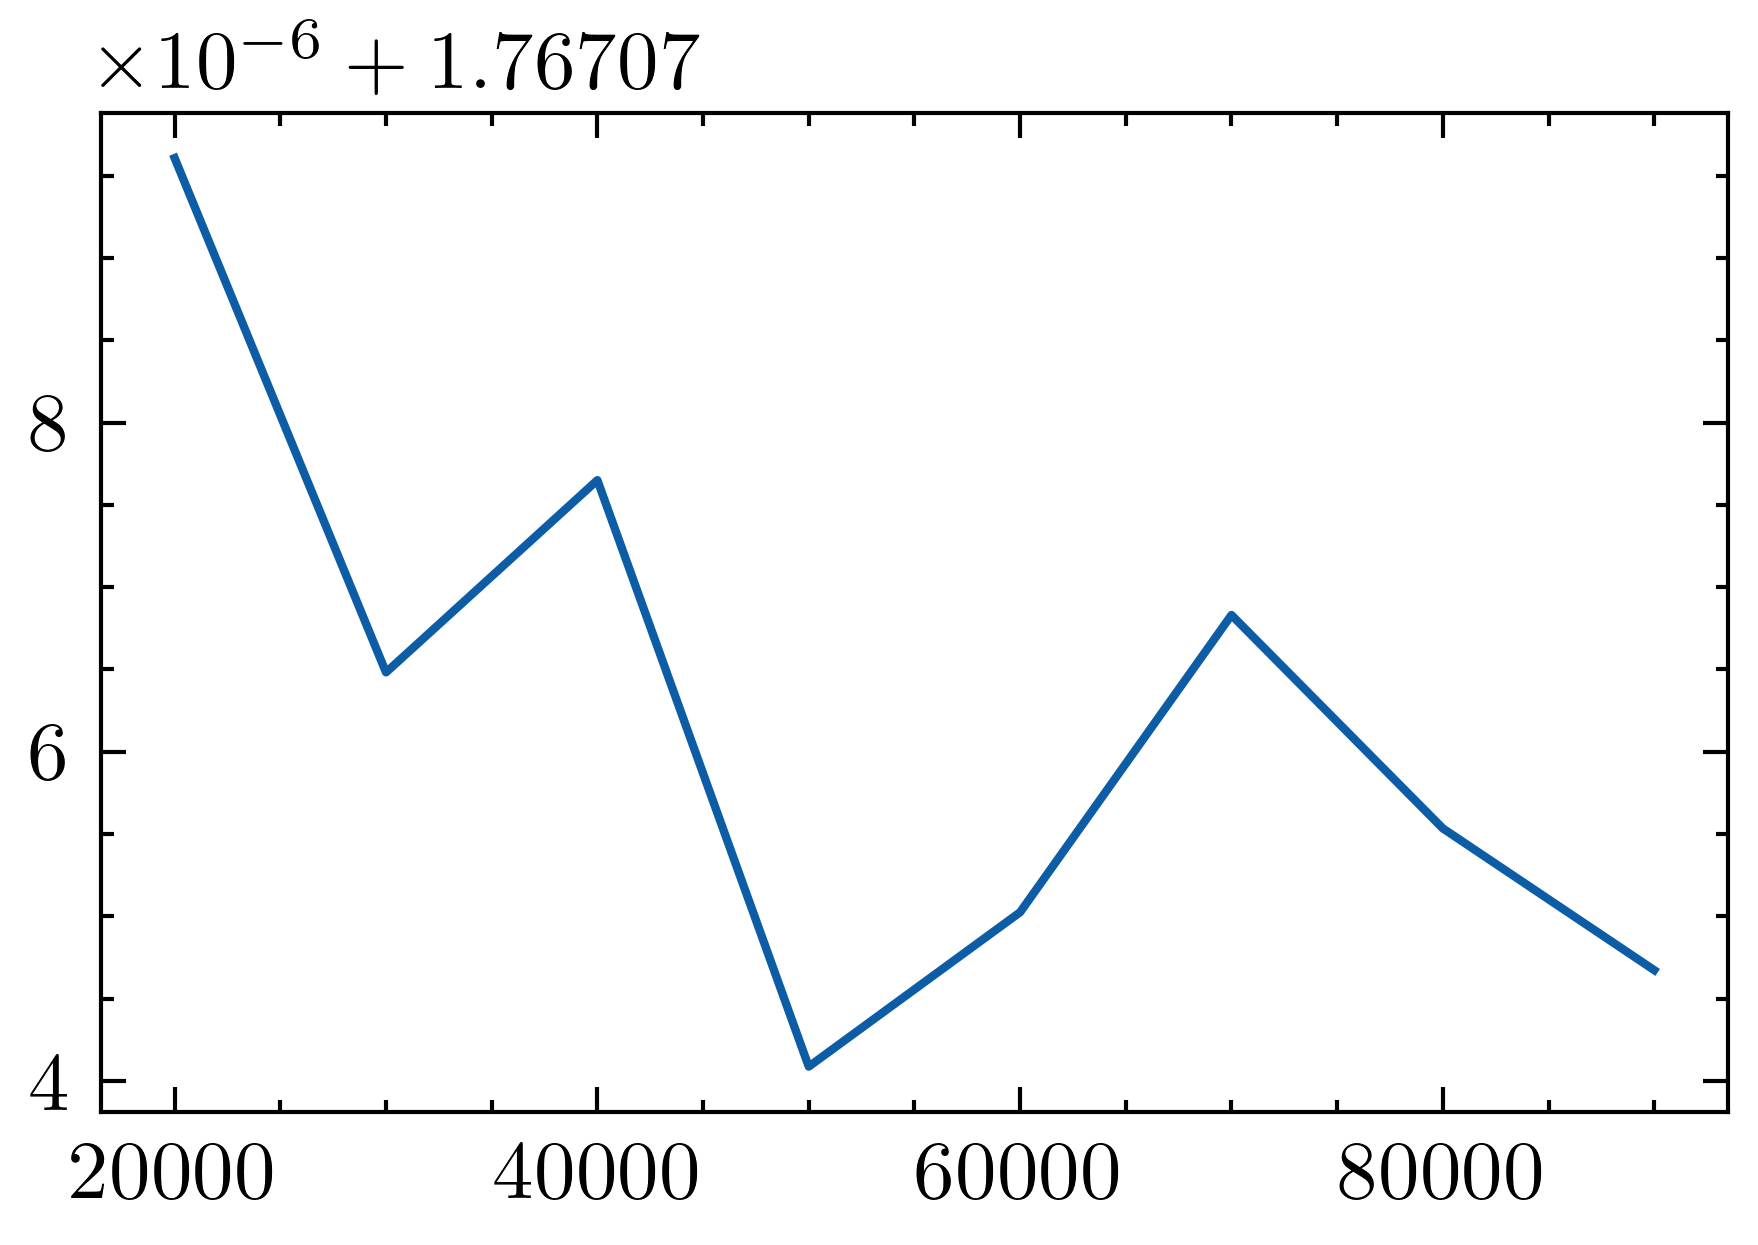

In [16]:
from scipy.integrate import trapezoid

results = []
samples = np.arange(20_000, 100_000, 10_000)

for sample in samples:
    alphas = np.geomspace(1, 1e6, sample)

    probs = fit.F(alphas, 0.47, Q = 1 / 0.3, g = 1, q = 1.3)
    finite_alphas = alphas[probs > 0]
    finite_probs = probs[probs > 0]

    res = np.abs(trapezoid(finite_alphas, finite_probs))

    results.append(res)


plt.plot(samples, results)